In [1]:
import os 
import warnings
import kagglehub
from pathlib import Path
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import shutil 
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

c:\Users\CoRe.2.Duo\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tf.random.set_seed(42)
np.random.seed(42)

In [ ]:
IMAGE_SIZE = (299, 299)
BATCH_SIZE = 32

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tawsifurrahman/covid19-radiography-database")

print("Path to dataset files:", path)

In [ ]:
RAW_DATASET_PATH = Path(path) / 'COVID-19_Radiography_Dataset' # Adjusted path to include nested folder
CLEAN_DATASET_PATH = Path('/content/COVID19_Cleaned_Dataset')

CATEGORIES = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
VALID_EXTENSIONS = {'.png', '.jpg', '.jpeg'}


CLEAN_DATASET_PATH.mkdir(parents=True, exist_ok=True)

print("🧹 Starting dataset cleanup...")

for category in CATEGORIES:
    clean_cat_dir = CLEAN_DATASET_PATH / category
    clean_cat_dir.mkdir(parents=True, exist_ok=True)


    cat_raw_dir = RAW_DATASET_PATH / category

    if not cat_raw_dir.exists():
        print(f"⚠️ Warning: Could not find directory for {category} at {cat_raw_dir}")
        continue

    copied_count = 0


    for file_path in cat_raw_dir.rglob('*'):
        if file_path.is_file() and file_path.suffix.lower() in VALID_EXTENSIONS:

            path_parts_lower = [part.lower() for part in file_path.parts]
            if any('mask' in part for part in path_parts_lower):
                continue


            dest_path = clean_cat_dir / file_path.name
            shutil.copy2(file_path, dest_path)
            copied_count += 1

    print(f"  - {category}: Copied {copied_count} images")

print("\n✅ Dataset cleaning complete!")import os


RAW_DATASET_PATH = Path(path) / 'COVID-19_Radiography_Dataset' # Adjusted path to include nested folder
CLEAN_DATASET_PATH = Path('/content/COVID19_Cleaned_Dataset')

CATEGORIES = ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
VALID_EXTENSIONS = {'.png', '.jpg', '.jpeg'}

# Create clean output directory
CLEAN_DATASET_PATH.mkdir(parents=True, exist_ok=True)

print("🧹 Starting dataset cleanup...")

for category in CATEGORIES:
    clean_cat_dir = CLEAN_DATASET_PATH / category
    clean_cat_dir.mkdir(parents=True, exist_ok=True)

    # Locate category directory regardless of exact path structure
    cat_raw_dir = RAW_DATASET_PATH / category

    if not cat_raw_dir.exists():
        print(f"⚠️ Warning: Could not find directory for {category} at {cat_raw_dir}")
        continue

    copied_count = 0

    # Recursively search for all files inside the category folder
    for file_path in cat_raw_dir.rglob('*'):
        if file_path.is_file() and file_path.suffix.lower() in VALID_EXTENSIONS:
            # Skip any file that has "mask" in its filename or in any parent folder name
            path_parts_lower = [part.lower() for part in file_path.parts]
            if any('mask' in part for part in path_parts_lower):
                continue

            # Copy image to clean destination folder
            dest_path = clean_cat_dir / file_path.name
            shutil.copy2(file_path, dest_path)
            copied_count += 1

    print(f"  - {category}: Copied {copied_count} images")

print("\n✅ Dataset cleaning complete!")

In [ ]:
raw_cat = [
    d for d in os.listdir(os.path.join(CLEAN_DATASET_PATH))
    if os.path.isdir(os.path.join(CLEAN_DATASET_PATH,d))
]
print(f"Catogires is: {raw_cat}")

Catogires is: ['COVID', 'Lung_Opacity', 'Normal', 'Output', 'Viral Pneumonia']


In [ ]:
filepaths = []
lables = []

for category in os.listdir(CLEAN_DATASET_PATH):
    cat_dir = os.path.join(CLEAN_DATASET_PATH,category)

    if os.path.isdir(cat_dir):
        for img_name in os.listdir(cat_dir):
            if img_name.lower().endswith(('.png','.jpg','.jpeg')):
                filepaths.append(os.path.join(cat_dir,img_name))
                lables.append(category)


df = pd.DataFrame({'filename':filepaths,'class':lables})


In [23]:
train_df , val_test_df = train_test_split (df , test_size=0.2,random_state= 42 , stratify=df['class'])
valid_df , test_df = train_test_split(val_test_df , test_size= 0.5 , random_state= 42 , stratify=val_test_df['class'])

print(f"train sample: {len(train_df)}")

print(f"test sample: {len(test_df)}")

print(f"validation sample: {len(valid_df)}")

train sample: 16932
test sample: 2117
validation sample: 2116


In [24]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function = preprocess_input,
    rotation_range = 15,
    width_shift_range = 0.08,  
    height_shift_range = 0.08,
    shear_range  = 0.08,
    zoom_range = 0.1,
    horizontal_flip = True,
    fill_mode='nearest'
)


val_and_test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function = preprocess_input
)

In [25]:
train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filename',
    y_col='class',
    target_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = True
)

test_gen = val_and_test_datagen.flow_from_dataframe(
    test_df,
    x_col='filename',
    y_col='class',
    target_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = False
)

valid_gen = val_and_test_datagen.flow_from_dataframe(
    valid_df,
    x_col='filename',
    y_col='class',
    target_size = IMAGE_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = False
)

Found 16932 validated image filenames belonging to 4 classes.
Found 2117 validated image filenames belonging to 4 classes.
Found 2116 validated image filenames belonging to 4 classes.


In [26]:
train_classes = train_gen.classes

class_weights_arr = compute_class_weight(
    class_weight= 'balanced',
    classes= np.unique(train_classes),
    y= train_classes
)

class_weight_dict = dict(enumerate(class_weights_arr))
 

In [27]:
base_model = DenseNet121 (weights='imagenet', include_top=False , input_shape=(299,299,3)) 
base_model.trainable = False

model = models.Sequential([
    base_model, 
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4,activation='softmax')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics = ['accuracy',
               tf.keras.metrics.Precision(name='precision'),
               tf.keras.metrics.Recall(name='recall')]
)

In [28]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 9, 9, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,173,316 (27.36 MB)

 Trainable params: 133,764 (522.52 KB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [29]:
callbacks_ph1 = [
    callbacks.EarlyStopping(monitor='val_loss',
                            patience= 5,
                            restore_best_weights= True,
                            verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss',
                                factor = 0.2,
                                patience = 2,
                                min_rlu=1e-5,
                                verbose=1),
    callbacks.ModelCheckpoint(filepath='best_densenet121_phase1.keras',
                              monitor='val_loss',
                              mode='min',
                              save_best_only=True,
                              verbose=1)
]

In [30]:
ph1 = model.fit(
    train_gen,
    epochs = 20,
    validation_data = valid_gen,
    callbacks = callbacks_ph1,
    class_weight = class_weight_dict
    
)

Epoch 1/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 963ms/step - accuracy: 0.7496 - loss: 0.5498 - precision: 0.7760 - recall: 0.7168
Epoch 1: val_loss improved from None to 0.37297, saving model to best_densenet121_phase1.keras

Epoch 1: finished saving model to best_densenet121_phase1.keras
530/530 ━━━━━━━━━━━━━━━━━━━━ 578s 1s/step - accuracy: 0.7496 - loss: 0.5498 - precision: 0.7760 - recall: 0.7168 - val_accuracy: 0.8677 - val_loss: 0.3730 - val_precision: 0.8783 - val_recall: 0.8455 - learning_rate: 0.0010
Epoch 2/20
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 901ms/step - accuracy: 0.8170 - loss: 0.3955 - precision: 0.8342 - recall: 0.7938
Epoch 2: val_loss improved from 0.37297 to 0.35599, saving model to best_densenet121_phase1.keras

Epoch 2: finished saving model to best_densenet121_phase1.keras
530/530 ━━━━━━━━━━━━━━━━━━━━ 543s 1s/step - accuracy: 0.8170 - loss: 0.3955 - precision: 0.8342 - recall: 0.7938 - val_accuracy: 0.8795 - val_loss: 0.3560 - val_precision: 0.8938 - val_recall: 0.8634 - l

In [31]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [34]:
callbacks_ph2 = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience= 7,
        restore_best_weights= True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        'best_densenet_chest.keras',
        monitor='val_loss',
        mode='min',
        save_best_only= True,
        verbose=1
    )
]

In [35]:
ph2 = model.fit(
    train_gen,
    epochs = 14,
    validation_data = valid_gen,
    callbacks=callbacks_ph2
)

Epoch 1/14
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 946ms/step - accuracy: 0.8982 - loss: 0.2691
Epoch 1: val_loss improved from None to 0.24913, saving model to best_densenet_chest.keras

Epoch 1: finished saving model to best_densenet_chest.keras
530/530 ━━━━━━━━━━━━━━━━━━━━ 562s 1s/step - accuracy: 0.8982 - loss: 0.2691 - val_accuracy: 0.9083 - val_loss: 0.2491 - learning_rate: 1.0000e-05
Epoch 2/14
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 939ms/step - accuracy: 0.8993 - loss: 0.2689
Epoch 2: val_loss did not improve from 0.24913
530/530 ━━━━━━━━━━━━━━━━━━━━ 556s 1s/step - accuracy: 0.8993 - loss: 0.2689 - val_accuracy: 0.9064 - val_loss: 0.2502 - learning_rate: 1.0000e-05
Epoch 3/14
530/530 ━━━━━━━━━━━━━━━━━━━━ 0s 931ms/step - accuracy: 0.9012 - loss: 0.2639
Epoch 3: val_loss improved from 0.24913 to 0.24538, saving model to best_densenet_chest.keras

Epoch 3: finished saving model to best_densenet_chest.keras
530/530 ━━━━━━━━━━━━━━━━━━━━ 553s 1s/step - accuracy: 0.9012 - loss: 0.2639 - val_accuracy


📊 Evaluating DenseNet121 on Test Set...
67/67 ━━━━━━━━━━━━━━━━━━━━ 59s 884ms/step - accuracy: 0.9107 - loss: 0.2323
Test Loss: 0.2323
Test Accuracy: 0.9107
67/67 ━━━━━━━━━━━━━━━━━━━━ 67s 951ms/step

Classification Report:
                 precision    recall  f1-score   support

          COVID       0.98      0.89      0.93       362
   Lung_Opacity       0.91      0.84      0.87       602
         Normal       0.89      0.96      0.92      1019
Viral Pneumonia       0.96      0.90      0.93       134

       accuracy                           0.91      2117
      macro avg       0.93      0.90      0.91      2117
   weighted avg       0.91      0.91      0.91      2117



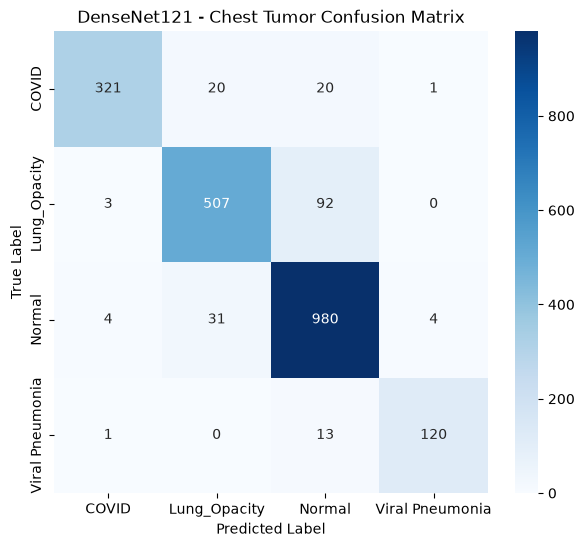

In [39]:
print("\n📊 Evaluating DenseNet121 on Test Set...")

# Evaluate the model
test_loss, test_acc = model.evaluate(test_gen)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Predictions & Evaluation Metrics
y_pred_probs = model.predict(test_gen)


y_pred = np.argmax(y_pred_probs, axis=1)

y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion Matrix Plot
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('DenseNet121 - Chest Tumor Confusion Matrix')
plt.show()